In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

from trading_library import *

In [2]:
# Directories
PROJECT = "C:/Users/skazempour/Dropbox/Projects/42 - Machine learning from the crowd/"
DATA = os.path.join(PROJECT, "Data")
FIGURES = os.path.join(PROJECT, "Figures")
CRSP_FOLDER = "D:/CRSP"

# Input files
INPUT_DATA = os.path.join(DATA, "merged_master.pkl")

# Models with two features only
LINEAR_REGRESSION_PREDICTIONS = os.path.join(DATA, "predictions_linear_regression.pkl")
DECISION_TREE_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree.pkl")
DECISION_TREE_SHALLOW_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree_shallow.pkl")
# DECISION_TREE_MODERATE_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree_moderate.pkl")
# DECISION_TREE_CONSTRAINED_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree_constrained.pkl")
# DECISION_TREE_CV_PRUNED_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree_cv_pruned.pkl")
# RANDOM_FOREST_PREDICTIONS = os.path.join(DATA, "predictions_random_forest.pkl")
# NEURAL_NETWORK_PREDICTIONS = os.path.join(DATA, "predictions_neural_network.pkl")
LASSO_PREDICTIONS = os.path.join(DATA, "predictions_lasso.pkl")
ELASTIC_NET_PREDICTIONS = os.path.join(DATA, "predictions_elasticnet.pkl")

# Models with all features
LINEAR_REGRESSION_ALL_FEATURES_PREDICTIONS = os.path.join(DATA, "predictions_linear_regression_all_features.pkl")
# DECISION_TREE_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree.pkl")
DECISION_TREE_SHALLOW_ALL_FEATURES_PREDICTIONS = os.path.join(DATA, "predictions_decision_tree_shallow_all_features.pkl")
LASSO_ALL_FEATURES_PREDICTIONS = os.path.join(DATA, "predictions_lasso_all_features.pkl")
ELASTIC_NET_ALL_FEATURES_PREDICTIONS = os.path.join(DATA, "predictions_elasticnet_all_features.pkl")
NEURAL_NETWORK_ALL_FEATURES_PREDICTIONS = os.path.join(DATA, "predictions_neural_network_all_features.pkl")

# Global parameters
START_DATE = "2012-01-01"
END_DATE = "2022-12-31"

# Putting together all predictions

In [5]:
# Load the original aggregated tweets data
master_data = pd.read_pickle(INPUT_DATA)
master_data = master_data[master_data['date'] >= '2012-01-01']

# Add the linear regression model
linear_regression_predictions = pd.read_pickle(LINEAR_REGRESSION_PREDICTIONS).drop(columns=['index', 'ticker'])
linear_regression_predictions.columns = ['date', 'permno', 'lr_exp', 'lr_roll_252', 'lr_roll_21']
df = pd.merge(master_data, linear_regression_predictions, on=['date', 'permno']) # Clean merge

In [6]:
# Add the decision tree model without prunning
decision_tree_predictions = pd.read_pickle(DECISION_TREE_PREDICTIONS).drop(columns=['index', 'ticker'])
decision_tree_predictions.columns = ['date', 'permno', 'dt_exp', 'dt_roll_252', 'dt_roll_21']
df = pd.merge(df, decision_tree_predictions, on=['date', 'permno']) # Clean merge

# Add the shallow decision tree model
decision_tree_shallow_predictions = pd.read_pickle(DECISION_TREE_SHALLOW_PREDICTIONS).drop(columns=['index', 'ticker'])
decision_tree_shallow_predictions.columns = ['date', 'permno', 'dt_shallow_exp', 'dt_shallow_roll_252', 'dt_shallow_roll_21']
df = pd.merge(df, decision_tree_shallow_predictions, on=['date', 'permno']) # Clean merge

# # Add the moderate decision tree model
# decision_tree_moderate_predictions = pd.read_pickle(DECISION_TREE_MODERATE_PREDICTIONS).drop(columns=['index'])
# decision_tree_moderate_predictions.columns = ['date', 'symbol', 'dt_moderate_exp', 'dt_moderate_roll_252', 'dt_moderate_roll_21']
# df = pd.merge(df, decision_tree_moderate_predictions, on=['date', 'symbol']) # Clean merge

# # Add the constrained decision tree model
# decision_tree_constrained_predictions = pd.read_pickle(DECISION_TREE_CONSTRAINED_PREDICTIONS).drop(columns=['index'])
# decision_tree_constrained_predictions.columns = ['date', 'symbol', 'dt_constrained_exp', 'dt_constrained_roll_252', 'dt_constrained_roll_21']
# df = pd.merge(df, decision_tree_constrained_predictions, on=['date', 'symbol']) # Clean merge

# # Add the cv pruned decision tree model
# decision_tree_cv_pruned_predictions = pd.read_pickle(DECISION_TREE_CV_PRUNED_PREDICTIONS).drop(columns=['index'])
# decision_tree_cv_pruned_predictions.columns = ['date', 'symbol', 'dt_cv_pruned_exp', 'dt_cv_pruned_roll_252', 'dt_cv_pruned_roll_21']
# df = pd.merge(df, decision_tree_cv_pruned_predictions, on=['date', 'symbol']) # Clean merge

# # Add the random forest model
# random_forest_predictions = pd.read_pickle(RANDOM_FOREST_PREDICTIONS).drop(columns=['index'])
# random_forest_predictions.columns = ['date', 'symbol', 'rf_exp', 'rf_roll_252', 'rf_roll_21']
# df = pd.merge(df, random_forest_predictions, on=['date', 'symbol']) # Clean merge

# # Add the neural network model
# neural_network_predictions = pd.read_pickle(NEURAL_NETWORK_PREDICTIONS).drop(columns=['index'])
# neural_network_predictions.columns = ['date', 'symbol', 'nn_exp', 'nn_roll_252', 'nn_roll_21']
# df = pd.merge(df, neural_network_predictions, on=['date', 'symbol']) # Clean merge

# Add the lasso model
lasso_predictions = pd.read_pickle(LASSO_PREDICTIONS).drop(columns=['index', 'ticker'])
lasso_predictions.columns = ['date', 'permno', 'lasso_exp', 'lasso_roll_252', 'lasso_roll_21']
df = pd.merge(df, lasso_predictions, on=['date', 'permno']) # Clean merge

# Add the elastic net model
elastic_net_predictions = pd.read_pickle(ELASTIC_NET_PREDICTIONS).drop(columns=['index', 'ticker'])
elastic_net_predictions.columns = ['date', 'permno', 'elastic_net_exp', 'elastic_net_roll_252', 'elastic_net_roll_21']
df = pd.merge(df, elastic_net_predictions, on=['date', 'permno']) # Clean merge

In [7]:
# Add the linear regression model with all features
linear_regression_all_features_predictions = pd.read_pickle(LINEAR_REGRESSION_ALL_FEATURES_PREDICTIONS).drop(columns=['index', 'ticker'])
linear_regression_all_features_predictions.columns = ['date', 'permno', 'lr_all_features_exp', 'lr_all_features_roll_252', 'lr_all_features_roll_21']
df = pd.merge(df, linear_regression_all_features_predictions, on=['date', 'permno']) # Clean merge

# # Add the decision tree model with all the features and without prunning
# decision_tree_predictions = pd.read_pickle(DECISION_TREE_PREDICTIONS).drop(columns=['index', 'ticker'])
# decision_tree_predictions.columns = ['date', 'permno', 'dt_all_features_exp', 'dt_all_features_roll_252', 'dt_all_features_roll_21']
# df = pd.merge(df, decision_tree_predictions, on=['date', 'permno']) # Clean merge

# Add the shallow decision tree model with all the features
decision_tree_shallow_all_features_predictions = pd.read_pickle(DECISION_TREE_SHALLOW_ALL_FEATURES_PREDICTIONS).drop(columns=['index', 'ticker'])
decision_tree_shallow_all_features_predictions.columns = ['date', 'permno', 'dt_shallow_all_features_exp', 'dt_shallow_all_features_roll_252', 'dt_shallow_all_features_roll_21']
df = pd.merge(df, decision_tree_shallow_all_features_predictions, on=['date', 'permno']) # Clean merge

# Add the lasso model with all features
lasso_all_features_predictions = pd.read_pickle(LASSO_ALL_FEATURES_PREDICTIONS).drop(columns=['index', 'ticker'])
lasso_all_features_predictions.columns = ['date', 'permno', 'lasso_all_features_exp', 'lasso_all_features_roll_252', 'lasso_all_features_roll_21']
df = pd.merge(df, lasso_all_features_predictions, on=['date', 'permno']) # Clean merge

# Add the elastic net model with all features
elastic_net_all_features_predictions = pd.read_pickle(ELASTIC_NET_ALL_FEATURES_PREDICTIONS).drop(columns=['index', 'ticker'])
elastic_net_all_features_predictions.columns = ['date', 'permno', 'elastic_net_all_features_exp', 'elastic_net_all_features_roll_252', 'elastic_net_all_features_roll_21']
df = pd.merge(df, elastic_net_all_features_predictions, on=['date', 'permno']) # Clean merge

# Add the neural network model with all features
neural_network_all_features_predictions = pd.read_pickle(NEURAL_NETWORK_ALL_FEATURES_PREDICTIONS).drop(columns=['index', 'ticker'])
neural_network_all_features_predictions.columns = ['date', 'permno', 'nn_all_features_roll_252']
df = pd.merge(df, neural_network_all_features_predictions, on=['date', 'permno']) # Clean merge

# Load the CRSP daily data

In [8]:
# Find all dsf_final_*.pkl files
crsp_files = sorted(glob.glob(os.path.join(CRSP_FOLDER, "dsf_final_*.pkl")))
print(f"Found {len(crsp_files)} CRSP files from {crsp_files[0]} to {crsp_files[-1]}.")

# Columns to keep
cols_to_keep = ['permno', 'date', 'cap', 'ret']

# Load and combine all files
crsp = [pd.read_pickle(file)[cols_to_keep] for file in tqdm(crsp_files)]

# Combine all dataframes
crsp = pd.concat(crsp, ignore_index=True)

# Clean the data
crsp['f_ret'] = crsp.groupby('permno')['ret'].shift(-1)
crsp['date'] = pd.to_datetime(crsp['date'])

Found 17 CRSP files from D:/CRSP\dsf_final_2008.pkl to D:/CRSP\dsf_final_2024.pkl.


  0%|          | 0/17 [00:00<?, ?it/s]

# Get the Fama-French data

In [9]:
# Download Fama-French 5 factors and momentum factor
import pandas_datareader.data as web

print("Downloading Fama-French 5 factors...", end='')
ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', start=START_DATE, end=END_DATE)[0]
ff5.index = pd.to_datetime(ff5.index, format='%Y%m%d')
ff5 = ff5 / 100  # Convert from percentage to decimal
print("Done!")

print("Downloading momentum factor...", end='')
mom = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=START_DATE, end=END_DATE)[0]
mom.index = pd.to_datetime(mom.index, format='%Y%m%d')
mom = mom / 100  # Convert from percentage to decimal
print("Done!")

# Merge FF5 and momentum into a single dataframe
ff_factors = pd.merge(ff5, mom, left_index=True, right_index=True, how='inner')

In [10]:
all_dates_to_use = np.sort(ff_factors.reset_index()['Date'].unique())
all_dates_to_use = all_dates_to_use[(all_dates_to_use >= pd.Timestamp(START_DATE)) & (all_dates_to_use <= pd.Timestamp(END_DATE))]

# Calculate portfolio returns

In [11]:
# List of all prediction columns to create portfolios from
prediction_columns = ['lr_exp', 'lr_roll_252', 'lr_roll_21',
                      'dt_exp', 'dt_roll_252', 'dt_roll_21',
                      'dt_shallow_exp', 'dt_shallow_roll_252', 'dt_shallow_roll_21',
                      'lasso_exp', 'lasso_roll_252', 'lasso_roll_21',
                      'elastic_net_exp', 'elastic_net_roll_252', 'elastic_net_roll_21',
                      'lr_all_features_exp', 'lr_all_features_roll_252', 'lr_all_features_roll_21',
                      'dt_shallow_all_features_exp', 'dt_shallow_all_features_roll_252', 'dt_shallow_all_features_roll_21',
                      'lasso_all_features_exp', 'lasso_all_features_roll_252', 'lasso_all_features_roll_21',
                      'elastic_net_all_features_exp', 'elastic_net_all_features_roll_252', 'elastic_net_all_features_roll_21',
                      'nn_all_features_roll_252']

# Dictionary to store portfolio returns for each prediction
portfolios = {}

# Calculate portfolio returns for each prediction signal
for pred_col in tqdm(prediction_columns, desc="Calculating portfolio returns"):
    # Form portfolios using the prediction as signal
    portfolio = form_portfolio_from_signals_sort(
        signals=df,
        returns=crsp,
        stock_col='permno',
        date_col='date',
        signal_col=pred_col,
        return_col='f_ret',
        bins=10,
        portfolio_weights=None,
        line_up_with=all_dates_to_use,
        shift=1
    )
    
    # Store in dictionary
    portfolios[pred_col] = portfolio

Calculating portfolio returns:   0%|          | 0/28 [00:00<?, ?it/s]

In [14]:
# Calculate portfolio returns with minimum stock requirements

# Define minimum stock thresholds
min_stocks_thresholds = [4, 10]

# Dictionary to store filtered portfolio returns
portfolios_filtered = {threshold: {} for threshold in min_stocks_thresholds}

for threshold in min_stocks_thresholds:
    print(f"\n{'='*80}")
    print(f"Calculating returns with minimum {threshold} stocks requirement")
    print(f"{'='*80}\n")
    
    for pred_col in prediction_columns:
        portfolio = portfolios[pred_col].copy()
        
        # Create filtered returns - set to 0 if fewer than threshold stocks
        portfolio_filtered = portfolio.copy()
        
        # For long side: set return to 0 if n_long < threshold
        portfolio_filtered.loc[portfolio['n_long'] < threshold, 'long_ret'] = 0
        portfolio_filtered.loc[portfolio['n_long'].isna(), 'long_ret'] = 0
        
        # For short side: set return to 0 if n_short < threshold
        portfolio_filtered.loc[portfolio['n_short'] < threshold, 'short_ret'] = 0
        portfolio_filtered.loc[portfolio['n_short'].isna(), 'short_ret'] = 0
        
        # Store filtered portfolio
        portfolios_filtered[threshold][pred_col] = portfolio_filtered
        
        # Calculate statistics for this portfolio
        n_days_long_original = portfolio['long_ret'].notna().sum()
        n_days_long_filtered = (portfolio_filtered['long_ret'] != 0).sum()
        
        n_days_short_original = portfolio['short_ret'].notna().sum()
        n_days_short_filtered = (portfolio_filtered['short_ret'] != 0).sum()
        
    # Calculate and display final cumulative returns
    print(f"\nFinal Log Cumulative Returns (minimum {threshold} stocks):")
    print("-" * 80)
    for pred_col in prediction_columns:
        portfolio_filtered = portfolios_filtered[threshold][pred_col]
        
        # Calculate long-short returns
        ls_ret = portfolio_filtered['long_ret'].fillna(0) - portfolio_filtered['short_ret'].fillna(0)
        
        # Calculate log cumulative returns
        log_cum_ret = np.log(1 + ls_ret).cumsum()
        final_value = log_cum_ret.iloc[-1]
        
        # Count trading days
        n_trading_days = (ls_ret != 0).sum()
        
        print(f"{pred_col:60s}: {final_value:>8.4f} ({np.exp(final_value)-1:>7.2%}) | Trading days: {n_trading_days:>4d}")

print(f"\n{'='*80}")
print("Comparison complete!")
print(f"{'='*80}")


Calculating returns with minimum 4 stocks requirement


Final Log Cumulative Returns (minimum 4 stocks):
--------------------------------------------------------------------------------
lr_exp                                                      :  -1.7564 (-82.73%) | Trading days: 2767
lr_roll_252                                                 :   0.2184 ( 24.40%) | Trading days: 2767
lr_roll_21                                                  :  -0.3484 (-29.42%) | Trading days: 2767
dt_exp                                                      :  -1.3031 (-72.83%) | Trading days: 2767
dt_roll_252                                                 :  -1.0703 (-65.71%) | Trading days: 2767
dt_roll_21                                                  :  -1.1456 (-68.20%) | Trading days: 2767
dt_shallow_exp                                              :  -0.7959 (-54.88%) | Trading days: 2767
dt_shallow_roll_252                                         :  -0.7255 (-51.59%) | Trading days: 27

# Plot log cumulative returns

Saved: log_cumulative_returns_linear_regression.png
Saved: log_cumulative_returns_decision_tree_full.png
Saved: log_cumulative_returns_decision_tree_shallow.png
Saved: log_cumulative_returns_lasso_regression.png
Saved: log_cumulative_returns_elastic_net_regression.png
Saved: log_cumulative_returns_linear_regression_all_features.png
Saved: log_cumulative_returns_decision_tree_shallow,_all_features.png
Saved: log_cumulative_returns_lasso_regression_all_features.png
Saved: log_cumulative_returns_elastic_net_regression_all_features.png
Saved: log_cumulative_returns_neural_network_all_features.png

Final Log Cumulative Returns (as of last date):
lr_exp                        :  -1.7564 (-82.73%)
lr_roll_252                   :   0.2184 ( 24.40%)
lr_roll_21                    :  -0.3484 (-29.42%)
dt_exp                        :  -1.3031 (-72.83%)
dt_roll_252                   :  -1.0703 (-65.71%)
dt_roll_21                    :  -1.1456 (-68.20%)
dt_shallow_exp                :  -0.7959 (-54

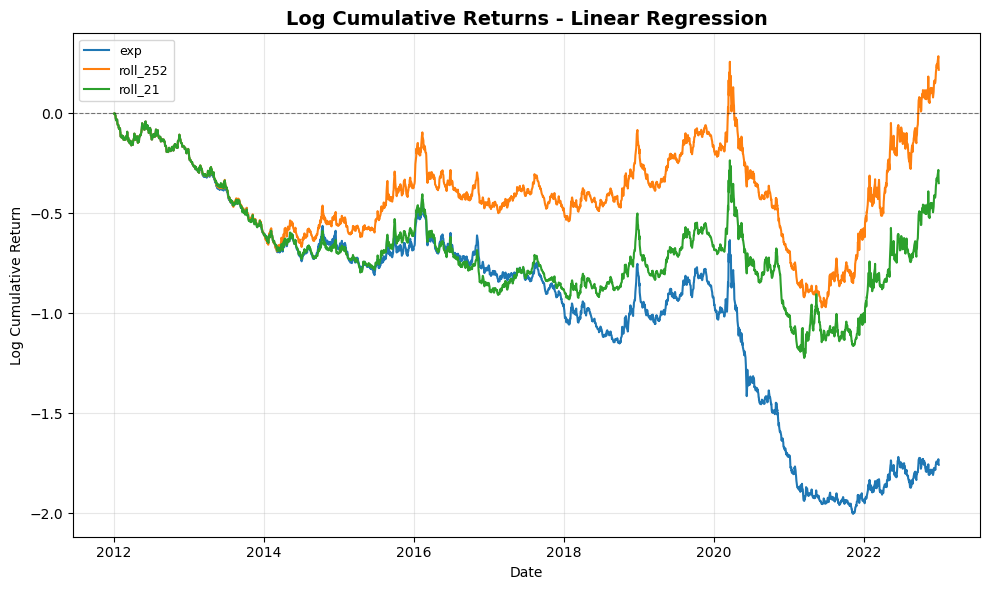

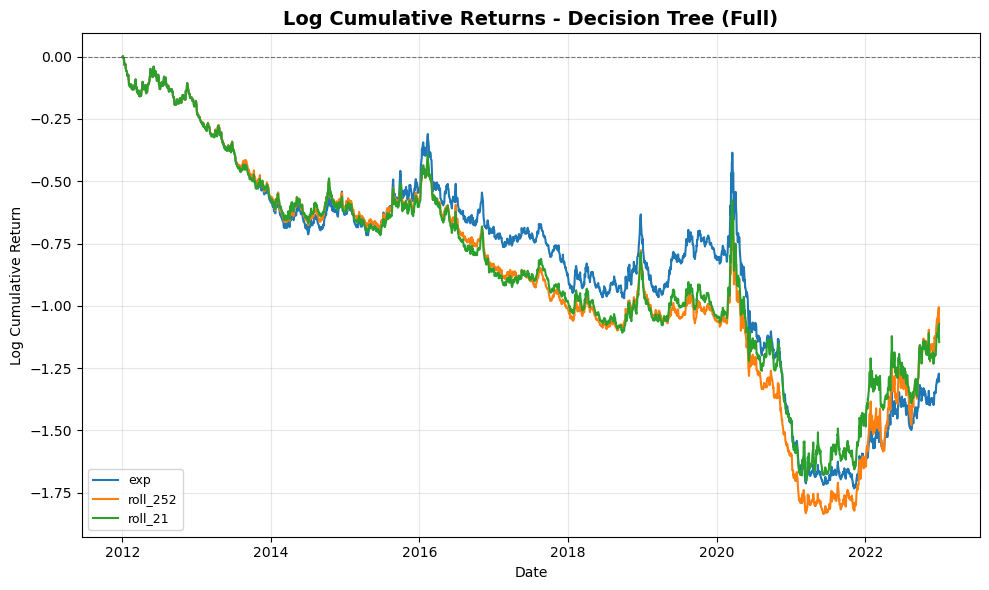

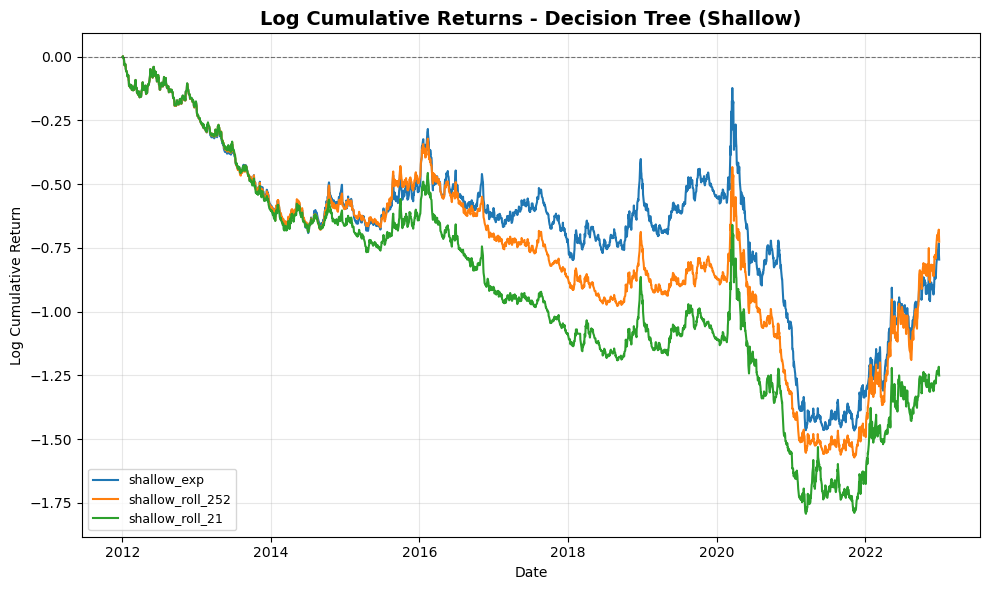

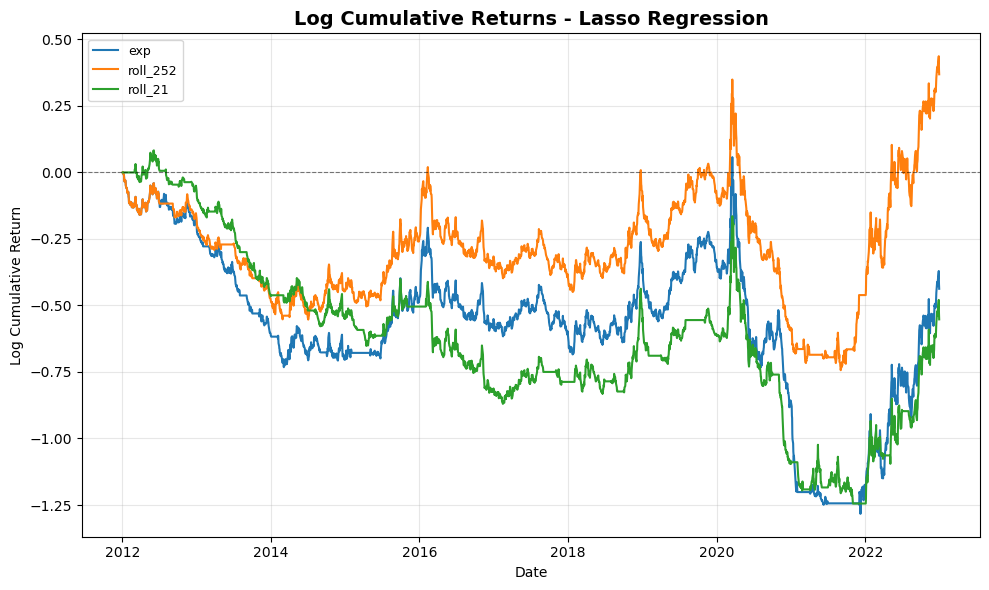

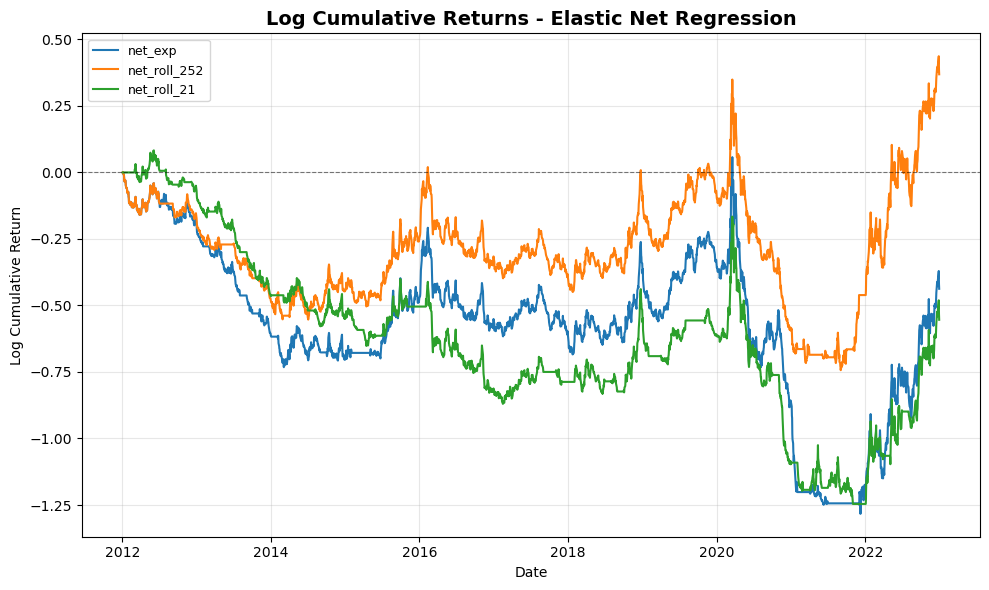

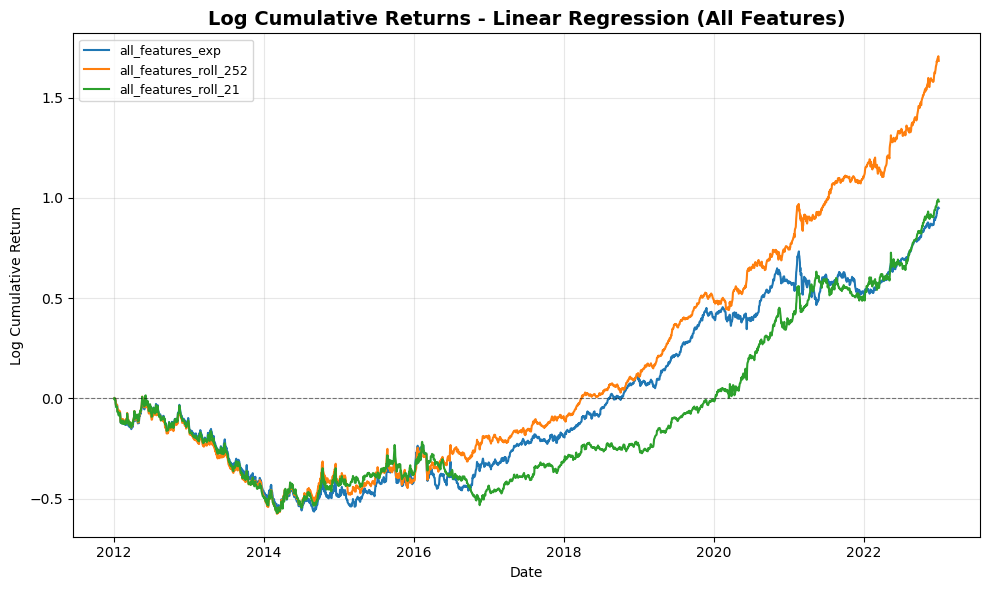

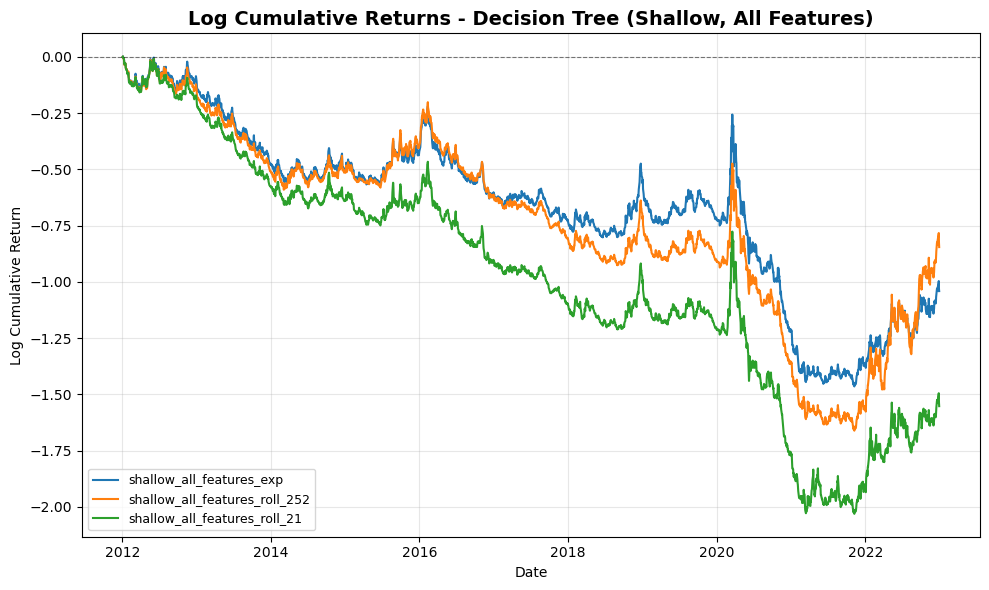

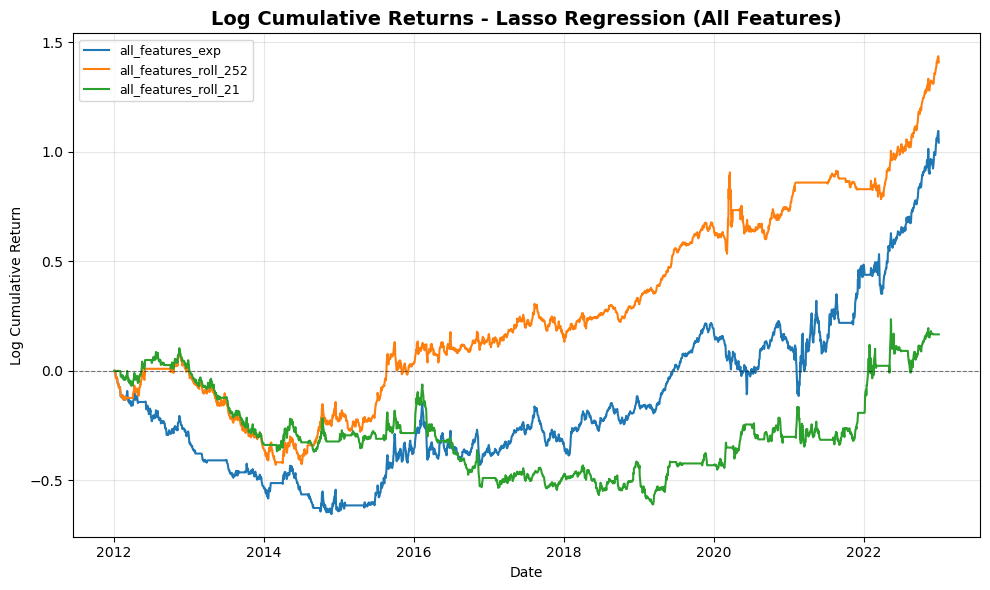

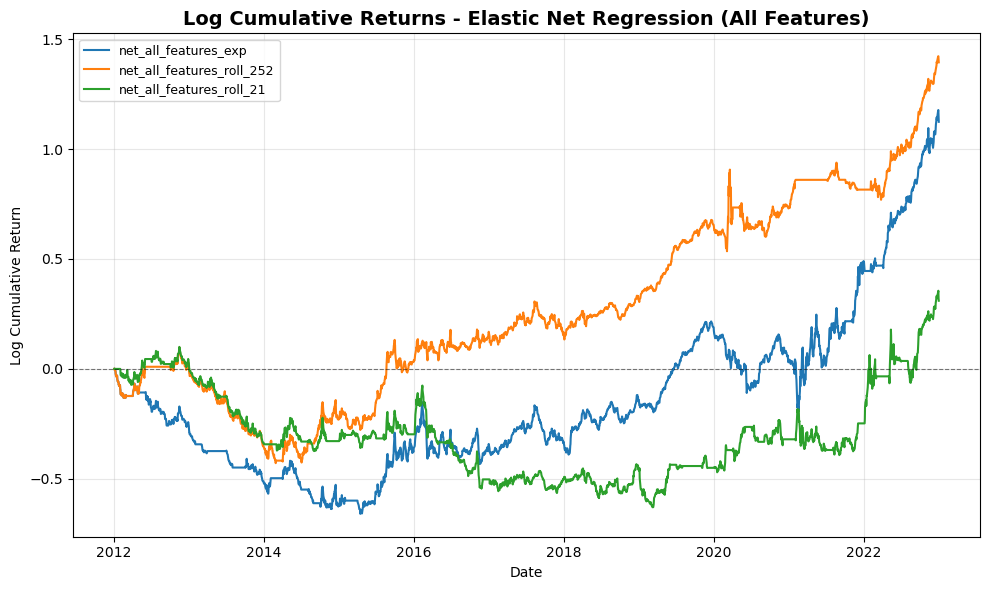

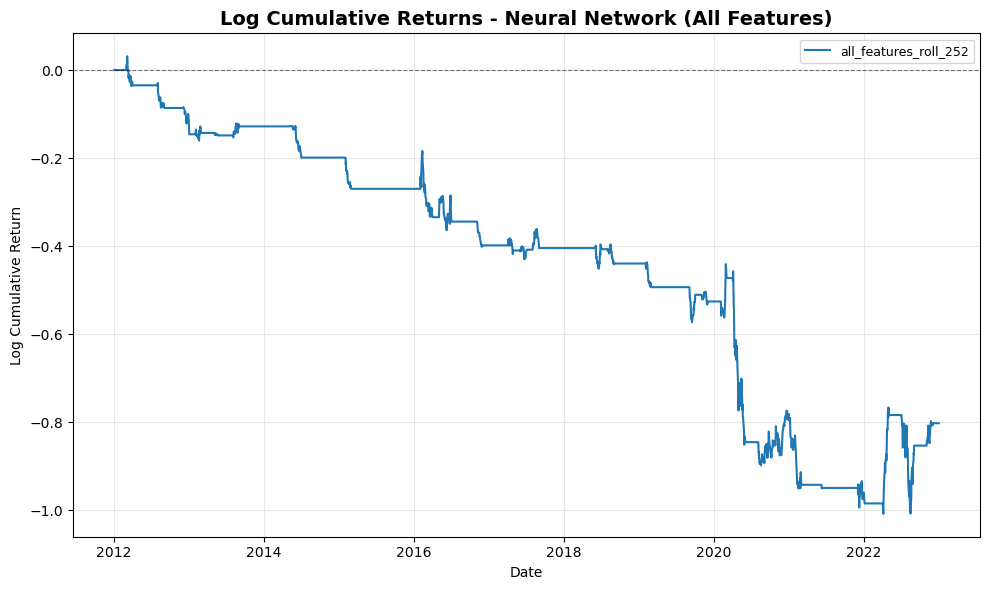

In [15]:
# Calculate log cumulative returns for each portfolio
# Create one plot per model and save to Figures directory

# Group predictions by model type
model_groups = {
    'Linear Regression': ['lr_exp', 'lr_roll_252', 'lr_roll_21'],
    'Decision Tree (Full)': ['dt_exp', 'dt_roll_252', 'dt_roll_21'],
    'Decision Tree (Shallow)': ['dt_shallow_exp', 'dt_shallow_roll_252', 'dt_shallow_roll_21'],
    # 'Decision Tree (Moderate)': ['dt_moderate_exp', 'dt_moderate_roll_252', 'dt_moderate_roll_21'],
    # 'Decision Tree (Constrained)': ['dt_constrained_exp', 'dt_constrained_roll_252', 'dt_constrained_roll_21'],
    # 'Decision Tree (CV Pruned)': ['dt_cv_pruned_exp', 'dt_cv_pruned_roll_252', 'dt_cv_pruned_roll_21'],
    # 'Random Forest': ['rf_exp', 'rf_roll_252', 'rf_roll_21'],
    # 'Neural Network': ['nn_exp', 'nn_roll_252', 'nn_roll_21'],
    'Lasso Regression': ['lasso_exp', 'lasso_roll_252', 'lasso_roll_21'],
    'Elastic Net Regression': ['elastic_net_exp', 'elastic_net_roll_252', 'elastic_net_roll_21'],
    'Linear Regression (All Features)': ['lr_all_features_exp', 'lr_all_features_roll_252', 'lr_all_features_roll_21'],
    'Decision Tree (Shallow, All Features)': ['dt_shallow_all_features_exp', 'dt_shallow_all_features_roll_252', 'dt_shallow_all_features_roll_21'],
    'Lasso Regression (All Features)': ['lasso_all_features_exp', 'lasso_all_features_roll_252', 'lasso_all_features_roll_21'],
    'Elastic Net Regression (All Features)': ['elastic_net_all_features_exp', 'elastic_net_all_features_roll_252', 'elastic_net_all_features_roll_21'],
    'Neural Network (All Features)': ['nn_all_features_roll_252']
}

# Create a filename-safe version of model names
def safe_filename(name):
    return name.lower().replace(' ', '_').replace('(', '').replace(')', '')

for model_name, pred_cols in model_groups.items():
    # Check if all prediction columns exist in portfolios
    if not all(col in portfolios for col in pred_cols):
        print(f"Skipping {model_name} - not all prediction columns available")
        continue
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for pred_col in pred_cols:
        portfolio = portfolios[pred_col]
        
        # Calculate long-short returns
        ls_ret = portfolio['long_ret'].fillna(0) - portfolio['short_ret'].fillna(0)
        
        # Calculate log cumulative returns
        log_cum_ret = np.log(1 + ls_ret).cumsum()
        
        # Extract label for legend (exp, roll_252, roll_21)
        label = pred_col.split('_', 1)[1] if '_' in pred_col else pred_col
        
        # Plot
        ax.plot(log_cum_ret.index, log_cum_ret.values, label=label, linewidth=1.5)
    
    ax.set_title(f'Log Cumulative Returns - {model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Log Cumulative Return', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    
    # Save the figure
    filename = f'log_cumulative_returns_{safe_filename(model_name)}.png'
    filepath = os.path.join(FIGURES, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filename}")
    
    # plt.show()

# Print summary statistics
print("\nFinal Log Cumulative Returns (as of last date):")
print("=" * 80)
for pred_col in prediction_columns:
    portfolio = portfolios[pred_col]
    ls_ret = portfolio['long_ret'].fillna(0) - portfolio['short_ret'].fillna(0)
    log_cum_ret = np.log(1 + ls_ret).cumsum()
    final_value = log_cum_ret.iloc[-1]
    print(f"{pred_col:30s}: {final_value:>8.4f} ({np.exp(final_value)-1:>7.2%})")

# Run time series tests

In [13]:
import statsmodels.api as sm
from latex_table import linear_regression

# Prepare the factor data
ff_factors_daily = ff_factors.copy() * 100  # Convert to percentage
ff_factors_daily['const'] = 1

# Use minimum 10 stocks portfolios as the main results
portfolios_to_test = portfolios_filtered[10]

# Calculate excess returns (long-short) for each portfolio and convert to percentage
portfolio_returns = {}
for pred_col in prediction_columns:
    portfolio = portfolios_to_test[pred_col]
    ls_ret = portfolio['long_ret'].fillna(0) - portfolio['short_ret'].fillna(0)
    portfolio_returns[pred_col] = ls_ret * 100  # Convert to percentage

# Merge all portfolio returns with factors
returns_df = pd.DataFrame(portfolio_returns)
returns_df.index.name = 'Date'

# Merge with factors
data = returns_df.merge(ff_factors_daily, left_index=True, right_index=True, how='inner')

print("Running time series regressions...")
print("=" * 80)

# Dictionary to store all regression results
regression_results = {
    'CAPM': [],
    'FF3': [],
    'FF5': [],
    'FF6': []
}

# Run regressions for each prediction column
for pred_col in prediction_columns:
    y = data[pred_col]
    
    # CAPM: alpha + beta * (Mkt-RF) + RF
    X_capm = data[['const', 'Mkt-RF']]
    model_capm = sm.OLS(y, X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    regression_results['CAPM'].append(model_capm)
    
    # FF3: alpha + Mkt-RF + SMB + HML
    X_ff3 = data[['const', 'Mkt-RF', 'SMB', 'HML']]
    model_ff3 = sm.OLS(y, X_ff3).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    regression_results['FF3'].append(model_ff3)
    
    # FF5: alpha + Mkt-RF + SMB + HML + RMW + CMA
    X_ff5 = data[['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    model_ff5 = sm.OLS(y, X_ff5).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    regression_results['FF5'].append(model_ff5)
    
    # FF6: FF5 + Mom
    X_ff6 = data[['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']]
    model_ff6 = sm.OLS(y, X_ff6).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    regression_results['FF6'].append(model_ff6)

print("Regressions complete!")
print(f"Total regressions run: {len(regression_results) * len(prediction_columns)}")

Running time series regressions...
Regressions complete!
Total regressions run: 84


In [14]:
# Create LaTeX tables for each factor model

# Define variable names for better display
var_names = {
    'const': 'Alpha',
    'Mkt-RF': 'Mkt-RF',
    'SMB': 'SMB',
    'HML': 'HML',
    'RMW': 'RMW',
    'CMA': 'CMA',
    'Mom': 'Mom'
}

# Column names (shortened for better display)
col_names_short = [
    'LR_exp', 'LR_252', 'LR_21',
    'DT_exp', 'DT_252', 'DT_21',
    'DTs_exp', 'DTs_252', 'DTs_21',
    # 'DTm_exp', 'DTm_252', 'DTm_21',
    # 'DTc_exp', 'DTc_252', 'DTc_21',
    # 'DTcv_exp', 'DTcv_252', 'DTcv_21',
    # 'RF_exp', 'RF_252', 'RF_21',
    # 'NN_exp', 'NN_252', 'NN_21',
    'Lasso_exp', 'Lasso_252', 'Lasso_21',
    'LRaf_exp', 'LRaf_252', 'LRaf_21',
    'DTsaf_exp', 'DTsaf_252', 'DTsaf_21',
    'Lassoaf_exp', 'Lassoaf_252', 'Lassoaf_21'
]

print("\n" + "=" * 80)
print("GENERATING LATEX TABLES (Returns already in percentage)")
print("=" * 80)

# Store tables for LaTeX export
latex_tables = {}

# CAPM Table
print("\n1. CAPM Model")
print("-" * 80)
tbl_capm = linear_regression(regression_results['CAPM'])
tbl_capm.set_var_list(['const', 'Mkt-RF'])
tbl_capm.rename_variables(var_names)
tbl_capm.rename_columns(col_names_short)
tbl_capm.aux_stat = 't'
tbl_capm.render(R2=True, obs=True)
latex_tables['CAPM'] = tbl_capm
print(tbl_capm.tbl.to_string())

# FF3 Table
print("\n2. Fama-French 3-Factor Model")
print("-" * 80)
tbl_ff3 = linear_regression(regression_results['FF3'])
tbl_ff3.set_var_list(['const', 'Mkt-RF', 'SMB', 'HML'])
tbl_ff3.rename_variables(var_names)
tbl_ff3.rename_columns(col_names_short)
tbl_ff3.aux_stat = 't'
tbl_ff3.render(R2=True, obs=True)
latex_tables['FF3'] = tbl_ff3
print(tbl_ff3.tbl.to_string())

# FF5 Table
print("\n3. Fama-French 5-Factor Model")
print("-" * 80)
tbl_ff5 = linear_regression(regression_results['FF5'])
tbl_ff5.set_var_list(['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'])
tbl_ff5.rename_variables(var_names)
tbl_ff5.rename_columns(col_names_short)
tbl_ff5.aux_stat = 't'
tbl_ff5.render(R2=True, obs=True)
latex_tables['FF5'] = tbl_ff5
print(tbl_ff5.tbl.to_string())

# FF6 Table
print("\n4. Fama-French 6-Factor Model (FF5 + Momentum)")
print("-" * 80)
tbl_ff6 = linear_regression(regression_results['FF6'])
tbl_ff6.set_var_list(['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom'])
tbl_ff6.rename_variables(var_names)
tbl_ff6.rename_columns(col_names_short)
tbl_ff6.aux_stat = 't'
tbl_ff6.render(R2=True, obs=True)
latex_tables['FF6'] = tbl_ff6
print(tbl_ff6.tbl.to_string())


GENERATING LATEX TABLES (Returns already in percentage)

1. CAPM Model
--------------------------------------------------------------------------------
                  LR_exp          LR_252           LR_21          DT_exp          DT_252           DT_21         DTs_exp         DTs_252          DTs_21       Lasso_exp       Lasso_252        Lasso_21        LRaf_exp        LRaf_252         LRaf_21       DTsaf_exp       DTsaf_252        DTsaf_21     Lassoaf_exp     Lassoaf_252      Lassoaf_21
Alpha              -0.00   0.08THREESTAR   0.06THREESTAR            0.02     0.03TWOSTAR     0.03ONESTAR     0.04TWOSTAR   0.04THREESTAR            0.02   0.06THREESTAR   0.09THREESTAR     0.04TWOSTAR   0.06THREESTAR   0.09THREESTAR   0.06THREESTAR     0.03TWOSTAR     0.03TWOSTAR            0.01   0.07THREESTAR   0.09THREESTAR            0.03
                 (-0.25)          (4.50)          (3.07)          (1.62)          (2.13)          (1.77)          (2.56)          (2.70)          (1.13)     